## Pip install and run code

In [7]:
pip install xgboost; catboost; lightgbm; shap; torchvision; torch

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 13.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/212.5 MB ? eta -:--:--
   ---------------------------------------- 2.6/212.5 MB 12.6 MB/s eta 0:00:17
    --------------------------------------- 5.2/212.5 MB 12.3 MB/s eta 0:00:17
   - -------------------------------------- 8.1/212.5 MB 12.6 MB/s eta 0:00:17
   -- ------------------------------------- 11.0/212.5 MB 13.0 MB/s eta 0:00:16
   -- ------------------------------------- 13.9/212.5 MB 13.0 MB/s eta 0:00:16
   --- ------------------------------------ 16.8/212.5 MB 13.1 MB/s eta 0:00:15
   --- ------------------------------------ 18.9/212.5 MB 13.1 MB/s eta 0:00:15
   --- ------------------------------------ 20.4/212.5 MB 12.0 MB/s eta 0:00:17
   ---- ----------------------------------- 23.1/212.5 MB 12.2 MB/s eta 0:00:16
   ---- ----------------------------------- 24.1/212.5 MB 11.4 MB/

In [11]:
import xgboost
print(xgboost.__version__)
import sys
print(sys.version)

3.0.0
3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]


# Load data

In [23]:
import pandas as pd

df = pd.read_csv("../filtered_data_v1.3.csv", index_col=0)
df = df.drop(["Unnamed: 0", "MCQ160B","MCQ160C","MCQ160E","SEQN_new"], axis=1)

# Feature importance

### Asthma

MCQ010
0.0    124807
1.0     19356
Name: count, dtype: int64


C:\Users\Hai\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:36:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


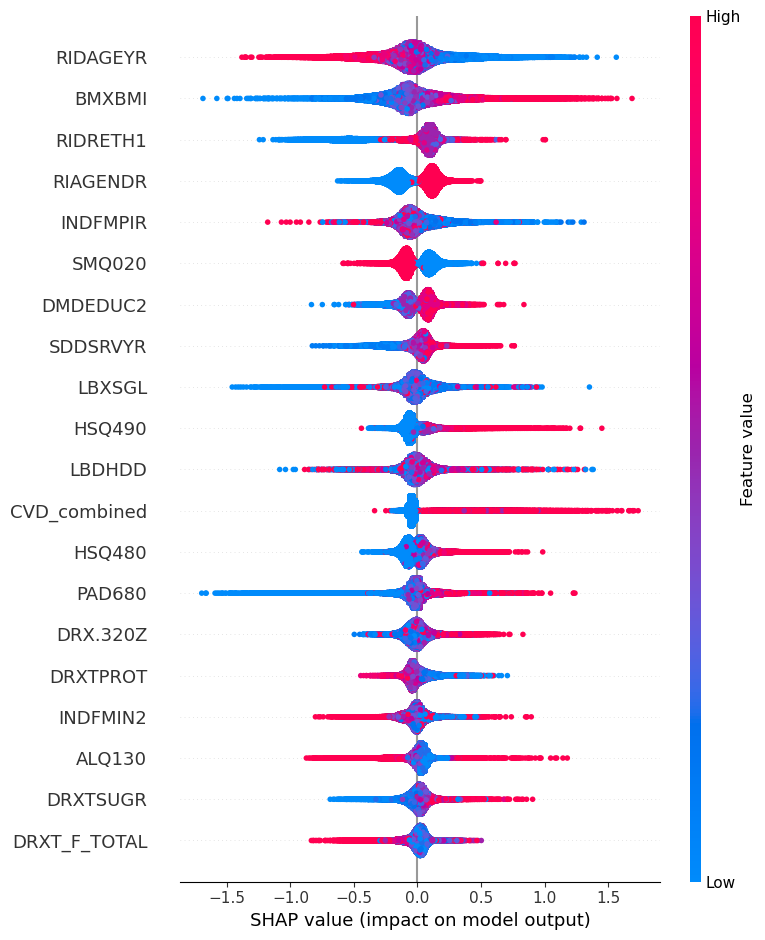

        DMDEDUC2  RIDAGEYR  RIAGENDR  INDFMPIR  SDDSRVYR  AIALANGA  RIDRETH1  \
0       0.127767  0.134774  0.183845  0.073241  0.281816  0.065940  0.196734   
1       0.140148  0.108101  0.190237  0.043405  0.368950  0.066403  0.081430   
2       0.252156  0.145089  0.219210  0.068690  0.229338  0.067388  0.295867   
3       0.113918  0.435047  0.038738  0.051118  0.099368  0.038121  0.071594   
4       0.096316  0.472820  0.046317  0.023304  0.097770  0.031427  0.039870   
...          ...       ...       ...       ...       ...       ...       ...   
144158  0.008467  0.161406  0.036539  0.038304  0.227893  0.185474  0.220016   
144159  0.003828  0.031738  0.063972  0.073679  0.127841  0.104867  0.483377   
144160  0.005005  0.085405  0.033456  0.003455  0.163431  0.217527  0.310911   
144161  0.185725  0.360263  0.010912  0.163651  0.183506  0.089884  0.457955   
144162  0.189240  0.347788  0.008285  0.167648  0.177128  0.086582  0.449088   

        INDFMIN2    PAQ620    ALQ130  .

In [18]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.combine import SMOTETomek
from sklearn.utils import resample
import numpy as np
import shap

# 1. Prepare your data

X = df.drop(columns=['MCQ010'])
y = df['MCQ010'].apply(lambda x: 2 if x >= 5 else x).replace({2: 0})  # Optional: convert to 0/1 if needed

print(y.value_counts())
# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train the model
model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42, n_jobs=-1,)
model.fit(X_train, y_train)
# 1. Get feature importance scores
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

shap_df = pd.DataFrame(np.abs(shap_values), columns=X.columns)
print(shap_df)

# Rank features by mean absolute SHAP value
mean_shap = shap_df.mean().sort_values(ascending=False)

important_features = mean_shap[mean_shap > 0.05].sort_values(ascending=False)

# Display
print(important_features)
# 2. Create a new DataFrame
df_important = df[important_features.index.tolist() + ['MCQ010']]  # Include target column MCQ010 too

# 3. Check
print(df_important.head())

### CVD

CVD_combined
0    132514
3      2468
2      2371
1      2075
6      1852
7      1274
5       902
4       707
Name: count, dtype: int64
CVD_combined
0    132514
1     11649
Name: count, dtype: int64


C:\Users\Hai\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:41:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


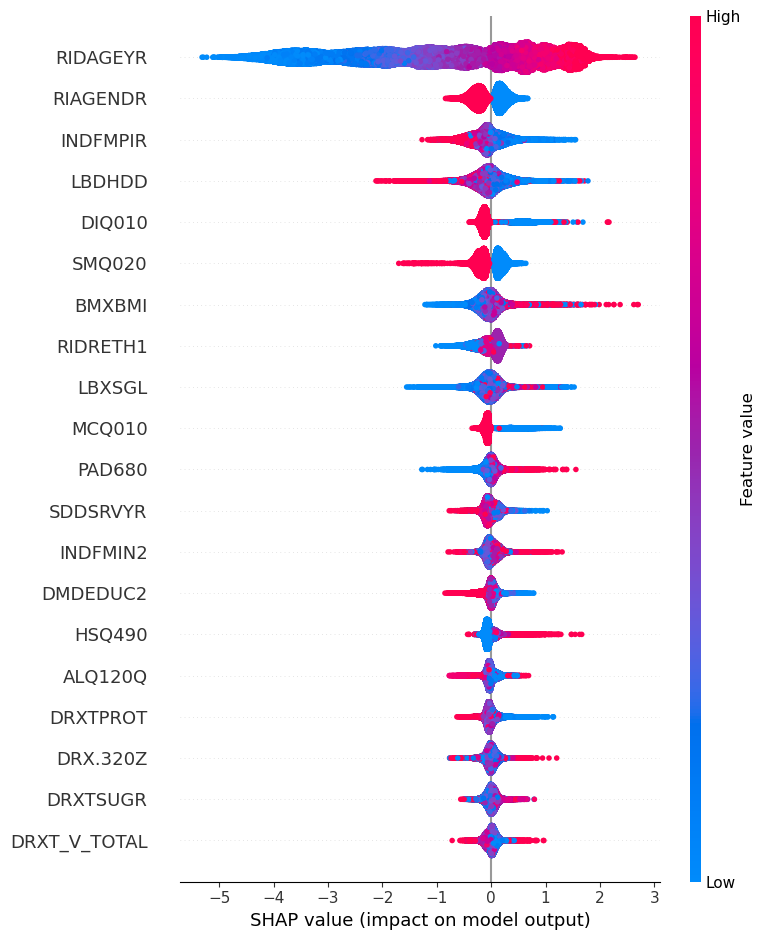

        DMDEDUC2  RIDAGEYR  RIAGENDR  INDFMPIR  SDDSRVYR  AIALANGA  RIDRETH1  \
0       0.019794  0.983398  0.230052  0.165373  0.086540  0.005616  0.165934   
1       0.000468  0.944505  0.197368  0.139391  0.027542  0.006267  0.179543   
2       0.028841  0.352498  0.153683  0.301880  0.042829  0.016958  0.386970   
3       0.004954  4.185044  0.267687  0.057283  0.242761  0.005360  0.029609   
4       0.014229  4.288080  0.307364  0.127431  0.152610  0.026025  0.044835   
...          ...       ...       ...       ...       ...       ...       ...   
144158  0.148757  0.525934  0.232619  0.148104  0.329556  0.098996  0.073966   
144159  0.160785  0.552943  0.240601  0.043070  0.312621  0.065227  0.136938   
144160  0.117838  0.495284  0.217522  0.119598  0.196823  0.051048  0.024690   
144161  0.060656  2.919734  0.131308  0.056854  0.534490  0.004879  0.226724   
144162  0.032986  3.164630  0.160024  0.131356  0.527692  0.005174  0.212454   

        INDFMIN2    PAQ620    ALQ130  .

In [25]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.combine import SMOTETomek
from sklearn.utils import resample
import numpy as np
import shap

# 1. Prepare your data

X = df.drop(columns=['CVD_combined'])
print(df['CVD_combined'].value_counts())
y = df['CVD_combined'].apply(lambda x: 1 if x > 1 else x)
print(y.value_counts())
# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train the model
model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42, n_jobs=-1,)
model.fit(X_train, y_train)
# 1. Get feature importance scores
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

shap_df = pd.DataFrame(np.abs(shap_values), columns=X.columns)
print(shap_df)

# Rank features by mean absolute SHAP value
mean_shap = shap_df.mean().sort_values(ascending=False)

important_features = mean_shap[mean_shap > 0.05].sort_values(ascending=False)

# Display
print(important_features)
# 2. Create a new DataFrame
df_important = df[important_features.index.tolist() + ['CVD_combined']]  # Include target column MCQ010 too

# 3. Check
print(df_important.head())

# Best results Confusion Matrix, F1, Recall and Precision (CatBoost and XGBoost)

In [3]:
# https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html

params_xgb_a = {'n_estimators': 1034, 'max_depth': 44, 'learning_rate': 0.002605778143121748, 'subsample': 0.9899332589658152, 'colsample_bytree': 0.6329045751941251, 'gamma': 0.05647630467219722, 'reg_alpha': 0.4193635968711551, 'reg_lambda': 0.6081298111535782, 'scale_pos_weight': 44.35864806295555}
params_xgb_cvd = {'n_estimators': 360, 'max_depth': 36, 'learning_rate': 0.0013884384418077122, 'subsample': 0.962856190450651, 'colsample_bytree': 0.704816748208964, 'gamma': 5.845426792598197, 'reg_alpha': 2.2052113183116138, 'reg_lambda': 0.9542414754046058, 'scale_pos_weight': 44.06802042290927}
params_cat_a = {'iterations': 1385, 'depth': 10, 'learning_rate': 0.12407678774584764, 'l2_leaf_reg': 0.20263510117341496, 'random_strength': 0.02925464732958274, 'bagging_temperature': 0.9797992558355522, 'scale_pos_weight': 20.821952368293346}
params_cat_cvd = {'iterations': 1390, 'depth': 10, 'learning_rate': 0.08007964023621864, 'l2_leaf_reg': 0.7784079079865358, 'random_strength': 0.017277475758399715, 'bagging_temperature': 0.19644159819379092, 'scale_pos_weight': 10.401148892606656}

# Hyperparameters tuning

## XGBoost 

Source
- https://www.kaggle.com/code/prashant111/a-guide-on-xgboost-hyperparameters-tuning
- https://xgboost.readthedocs.io/en/stable/tutorials/param_tuning.html
- https://xgboost.readthedocs.io/en/stable/python/python_api.html

- https://catboost.ai/docs/en/concepts/python-reference_catboostclassifier
- https://catboost.ai/docs/en/concepts/parameter-tuning

### Asthma

In [14]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

# Step 1: Create objective function
from sklearn.metrics import precision_score, recall_score

def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1500),
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 5.0, 50.0)
    }

    model = xgb.XGBClassifier(**params, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)
    #model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_val)

    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)

    return precision, recall  # multi-objective!

# Step 2: Calculate scale_pos_weight from class imbalance
scale = y.value_counts()[0] / y.value_counts()[1]

# Step 3: Train-test split again for consistency
X = df_important.drop(columns=['MCQ010'])
y = df_important['MCQ010'].apply(lambda x: 2 if x >= 5 else x).replace({2: 0})  # Optional: convert to 0/1 if needed

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)


def print_best_callback(study, trial):
    global best_qualified_trial
    precision, recall = trial.values
    score_sum = precision + recall

    if precision > 0.8 and recall > 0.8:
        print(f"[🎯 QUALIFIED] Trial #{trial.number} — Precision: {precision:.4f}, Recall: {recall:.4f}, Sum: {score_sum:.4f}")
        if score_sum > best_qualified_trial["score_sum"]:
            best_qualified_trial["trial"] = trial
            best_qualified_trial["score_sum"] = score_sum
    else:
        # Always print current best (even if this one doesn't qualify)
        best = max(
            [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
            key=lambda t: t.values[0] + t.values[1],
            default=None
        )
        if best:
            p, r = best.values
            print(f"[  Best So Far ] Trial #{best.number} — Precision: {p:.4f}, Recall: {r:.4f}, Sum: {p + r:.4f}")

# Run optimization
best_qualified_trial = {"trial": None, "score_sum": 0.0}
study = optuna.create_study(directions=["maximize", "maximize"])
study.optimize(objective, n_trials=1000, callbacks=[print_best_callback])

# Print final best trial (with both precision and recall > 0.8)
final = best_qualified_trial["trial"]
if final:
    precision, recall = final.values
    print(f"\n✅ Best Qualified Trial (Precision & Recall > 0.8): #{final.number}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print("  Params:")
    for k, v in final.params.items():
        print(f"    {k}: {v}")
else:
    print("\n❌ No trial had both precision and recall above 0.8.")


[I 2025-05-08 03:32:59,982] A new study created in memory with name: no-name-372b6680-fd3b-489a-8cc2-6d929ab70513
[I 2025-05-08 03:34:01,364] Trial 0 finished with values: [0.5206511908350919, 0.8925064599483205] and parameters: {'n_estimators': 794, 'max_depth': 30, 'learning_rate': 0.002793990456818809, 'subsample': 0.8931248133930153, 'colsample_bytree': 0.7703726470756616, 'gamma': 0.0012658463869452685, 'reg_alpha': 5.447506071463776, 'reg_lambda': 1.8843397301637677, 'scale_pos_weight': 20.233481348076676}.


[  Best So Far ] Trial #0 — Precision: 0.5207, Recall: 0.8925, Sum: 1.4132


[I 2025-05-08 03:34:02,756] Trial 1 finished with values: [0.3456833275078644, 0.5111111111111111] and parameters: {'n_estimators': 343, 'max_depth': 8, 'learning_rate': 0.020763824733986514, 'subsample': 0.8848779219673877, 'colsample_bytree': 0.7569456388503315, 'gamma': 5.79024656083662, 'reg_alpha': 4.045822277755613, 'reg_lambda': 3.4751947280945137, 'scale_pos_weight': 5.363117961304874}.


[  Best So Far ] Trial #0 — Precision: 0.5207, Recall: 0.8925, Sum: 1.4132


[I 2025-05-08 03:34:26,728] Trial 2 finished with values: [0.32894482090997096, 0.8780361757105943] and parameters: {'n_estimators': 1265, 'max_depth': 45, 'learning_rate': 0.0025786595443661156, 'subsample': 0.6740564234523665, 'colsample_bytree': 0.6758794961885104, 'gamma': 8.881664833115293, 'reg_alpha': 3.116754561424936, 'reg_lambda': 8.422583353787372, 'scale_pos_weight': 13.727674319816417}.


...

[  Best So Far ] Trial #943 — Precision: 0.9576, Recall: 0.8289, Sum: 1.7866


[I 2025-05-08 14:04:02,235] Trial 998 finished with values: [0.9419695193434936, 0.8304909560723515] and parameters: {'n_estimators': 1332, 'max_depth': 35, 'learning_rate': 0.0038757188433898608, 'subsample': 0.9694713004861217, 'colsample_bytree': 0.7703726470756616, 'gamma': 0.12634882747818654, 'reg_alpha': 0.6470882747437368, 'reg_lambda': 1.8843397301637677, 'scale_pos_weight': 45.36051264745938}.


[🎯 QUALIFIED] Trial #998 — Precision: 0.9420, Recall: 0.8305, Sum: 1.7725


[I 2025-05-08 14:05:14,136] Trial 999 finished with values: [0.44189453125, 0.9354005167958657] and parameters: {'n_estimators': 764, 'max_depth': 30, 'learning_rate': 0.0015435667929585466, 'subsample': 0.963827499185086, 'colsample_bytree': 0.7689215846036175, 'gamma': 0.12634882747818654, 'reg_alpha': 0.4360644939396874, 'reg_lambda': 3.7403841935637203, 'scale_pos_weight': 20.29441321662513}.


[  Best So Far ] Trial #943 — Precision: 0.9576, Recall: 0.8289, Sum: 1.7866

✅ Best Qualified Trial (Precision & Recall > 0.8): #943
  Precision: 0.9576
  Recall:    0.8289
  Params:
    n_estimators: 764
    max_depth: 44
    learning_rate: 0.013080265524936763
    subsample: 0.9694713004861217
    colsample_bytree: 0.6537830846296673
    gamma: 0.8703155905618276
    reg_alpha: 0.6470882747437368
    reg_lambda: 1.0186999108910388
    scale_pos_weight: 44.94138008500907


### CVD

In [28]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

# Step 1: Create objective function
from sklearn.metrics import precision_score, recall_score

def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1500),
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 5.0, 50.0)
    }

    model = xgb.XGBClassifier(**params, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)
    #model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_val)

    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)

    return precision, recall  # multi-objective!

# Step 2: Calculate scale_pos_weight from class imbalance
scale = y.value_counts()[0] / y.value_counts()[1]

# Step 3: Train-test split again for consistency
X = df_important.drop(columns=['CVD_combined'])
y = df_important['CVD_combined'].apply(lambda x: 1 if x > 1 else x)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)


def print_best_callback(study, trial):
    global best_qualified_trial
    precision, recall = trial.values
    score_sum = precision + recall

    if precision > 0.8 and recall > 0.8:
        print(f"[🎯 QUALIFIED] Trial #{trial.number} — Precision: {precision:.4f}, Recall: {recall:.4f}, Sum: {score_sum:.4f}")
        if score_sum > best_qualified_trial["score_sum"]:
            best_qualified_trial["trial"] = trial
            best_qualified_trial["score_sum"] = score_sum
    else:
        # Always print current best (even if this one doesn't qualify)
        best = max(
            [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
            key=lambda t: t.values[0] + t.values[1],
            default=None
        )
        if best:
            p, r = best.values
            print(f"[  Best So Far ] Trial #{best.number} — Precision: {p:.4f}, Recall: {r:.4f}, Sum: {p + r:.4f}")

# Run optimization
best_qualified_trial = {"trial": None, "score_sum": 0.0}
study = optuna.create_study(directions=["maximize", "maximize"])
study.optimize(objective, n_trials=1000, callbacks=[print_best_callback])

# Print final best trial (with both precision and recall > 0.8)
final = best_qualified_trial["trial"]
if final:
    precision, recall = final.values
    print(f"\n✅ Best Qualified Trial (Precision & Recall > 0.8): #{final.number}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print("  Params:")
    for k, v in final.params.items():
        print(f"    {k}: {v}")
else:
    print("\n❌ No trial had both precision and recall above 0.8.")


[I 2025-05-09 04:15:23,558] A new study created in memory with name: no-name-f494f960-1c71-4f23-acba-dde9ee83ef9d
[I 2025-05-09 04:15:27,186] Trial 0 finished with values: [0.39046579330422126, 0.9210300429184549] and parameters: {'n_estimators': 670, 'max_depth': 30, 'learning_rate': 0.053222140873984865, 'subsample': 0.9902187089743205, 'colsample_bytree': 0.9667562161952212, 'gamma': 8.540138897932376, 'reg_alpha': 3.1190544387129515, 'reg_lambda': 8.754088038200548, 'scale_pos_weight': 44.57856951632438}.


[  Best So Far ] Trial #0 — Precision: 0.3905, Recall: 0.9210, Sum: 1.3115


[I 2025-05-09 04:15:30,628] Trial 1 finished with values: [0.3404099560761347, 0.7982832618025751] and parameters: {'n_estimators': 324, 'max_depth': 45, 'learning_rate': 0.0169932916673174, 'subsample': 0.553111658218354, 'colsample_bytree': 0.6413707562480924, 'gamma': 9.52695305622276, 'reg_alpha': 5.776297252409672, 'reg_lambda': 4.1016229112961184, 'scale_pos_weight': 9.376050231650035}.


[  Best So Far ] Trial #0 — Precision: 0.3905, Recall: 0.9210, Sum: 1.3115


[I 2025-05-09 04:15:34,761] Trial 2 finished with values: [0.3897196261682243, 0.7158798283261802] and parameters: {'n_estimators': 1331, 'max_depth': 37, 'learning_rate': 0.14307451562007534, 'subsample': 0.5178378345734665, 'colsample_bytree': 0.8083050854372332, 'gamma': 7.745028409694101, 'reg_alpha': 9.979244057132096, 'reg_lambda': 7.507059469167814, 'scale_pos_weight': 7.762071609644393}.


...

[🎯 QUALIFIED] Trial #997 — Precision: 0.8049, Recall: 0.8498, Sum: 1.6547


[I 2025-05-09 12:22:51,948] Trial 998 finished with values: [0.4606112785191563, 0.9184549356223176] and parameters: {'n_estimators': 900, 'max_depth': 25, 'learning_rate': 0.0015931668522534642, 'subsample': 0.9389394106838905, 'colsample_bytree': 0.8083050854372332, 'gamma': 0.1481636150726262, 'reg_alpha': 0.62784772040401, 'reg_lambda': 2.126562486968723, 'scale_pos_weight': 33.861608841914155}.


[  Best So Far ] Trial #973 — Precision: 0.9307, Recall: 0.7957, Sum: 1.7264


[I 2025-05-09 12:23:11,442] Trial 999 finished with values: [0.9087340529931305, 0.7948497854077253] and parameters: {'n_estimators': 517, 'max_depth': 42, 'learning_rate': 0.04279808825876251, 'subsample': 0.9902187089743205, 'colsample_bytree': 0.8382537479387142, 'gamma': 0.045977657614418854, 'reg_alpha': 0.62784772040401, 'reg_lambda': 0.9567175770883607, 'scale_pos_weight': 42.738172016555545}.


[  Best So Far ] Trial #973 — Precision: 0.9307, Recall: 0.7957, Sum: 1.7264

✅ Best Qualified Trial (Precision & Recall > 0.8): #887
  Precision: 0.8982
  Recall:    0.8180
  Params:
    n_estimators: 1433
    max_depth: 44
    learning_rate: 0.009610155634369575
    subsample: 0.9902187089743205
    colsample_bytree: 0.9667562161952212
    gamma: 0.1481636150726262
    reg_alpha: 0.5400313257764566
    reg_lambda: 0.5340996109501062
    scale_pos_weight: 39.248828599728064


In [11]:
print("\n📌 Trials with Precision and Recall >= 0.85:")
qualified_trials = [
    t for t in study.trials
    if t.state == optuna.trial.TrialState.COMPLETE and
       t.values[0] >= 0.85 and t.values[1] >= 0.85
]

if qualified_trials:
    for t in sorted(qualified_trials, key=lambda t: -(t.values[0] + t.values[1])):
        print(f"Trial #{t.number} — Precision: {t.values[0]:.4f}, Recall: {t.values[1]:.4f}, Sum: {t.values[0] + t.values[1]:.4f}")
else:
    print("No trial met the criteria.")



📌 Trials with Precision and Recall >= 0.85:
Trial #648 — Precision: 0.8845, Recall: 0.8548, Sum: 1.7393
Trial #742 — Precision: 0.8845, Recall: 0.8548, Sum: 1.7393
Trial #583 — Precision: 0.8872, Recall: 0.8509, Sum: 1.7381
Trial #624 — Precision: 0.8872, Recall: 0.8509, Sum: 1.7381
Trial #955 — Precision: 0.8571, Recall: 0.8631, Sum: 1.7202
Trial #47 — Precision: 0.8540, Recall: 0.8600, Sum: 1.7140
Trial #703 — Precision: 0.8554, Recall: 0.8546, Sum: 1.7100


## CatBoost

### Asthma

In [15]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

# Step 1: Prepare data
X = df_important.drop(columns=['MCQ010'])
y = df_important['MCQ010'].apply(lambda x: 2 if x >= 5 else x).replace({2: 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)


# Step 2: Define objective function
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1500),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-2, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 5.0, 50.0),
        'verbose': 0,
        'random_seed': 42,
        'task_type': 'CPU',  # Change to 'GPU' if you're using GPU
        'loss_function': 'Logloss',
        'eval_metric': 'Logloss'
    }

    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)

    return precision, recall

# Step 3: Callback for best trial with precision & recall > 0.8
def print_best_callback(study, trial):
    global best_qualified_trial
    precision, recall = trial.values
    score_sum = precision + recall

    if precision > 0.8 and recall > 0.8:
        print(f"[🎯 QUALIFIED] Trial #{trial.number} — Precision: {precision:.4f}, Recall: {recall:.4f}, Sum: {score_sum:.4f}")
        if score_sum > best_qualified_trial["score_sum"]:
            best_qualified_trial["trial"] = trial
            best_qualified_trial["score_sum"] = score_sum
    else:
        best = max(
            [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
            key=lambda t: t.values[0] + t.values[1],
            default=None
        )
        if best:
            p, r = best.values
            print(f"[  Best So Far ] Trial #{best.number} — Precision: {p:.4f}, Recall: {r:.4f}, Sum: {p + r:.4f}")

# Step 4: Run the study
best_qualified_trial = {"trial": None, "score_sum": 0.0}
study = optuna.create_study(directions=["maximize", "maximize"])
study.optimize(objective, n_trials=1000, callbacks=[print_best_callback])

# Step 5: Print final result
final = best_qualified_trial["trial"]
if final:
    precision, recall = final.values
    print(f"\n✅ Best Qualified Trial (Precision & Recall > 0.8): #{final.number}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print("  Params:")
    for k, v in final.params.items():
        print(f"    {k}: {v}")
else:
    print("\n❌ No trial had both precision and recall above 0.8.")


[I 2025-05-08 14:05:14,370] A new study created in memory with name: no-name-3a32441e-365d-4783-a761-58d3992aa0a3
[I 2025-05-08 14:05:28,202] Trial 0 finished with values: [0.5261928595261929, 0.8149870801033592] and parameters: {'iterations': 533, 'depth': 9, 'learning_rate': 0.2797842791359842, 'l2_leaf_reg': 0.06536401855858882, 'random_strength': 0.135763555681178, 'bagging_temperature': 0.20302033035333977, 'scale_pos_weight': 28.964206262585325}.


[  Best So Far ] Trial #0 — Precision: 0.5262, Recall: 0.8150, Sum: 1.3412


[I 2025-05-08 14:05:56,350] Trial 1 finished with values: [0.14450648958647752, 0.9896640826873385] and parameters: {'iterations': 1333, 'depth': 5, 'learning_rate': 0.03653235919454812, 'l2_leaf_reg': 0.11117297644231738, 'random_strength': 0.5282102398017517, 'bagging_temperature': 0.11848894002070276, 'scale_pos_weight': 44.26823652642002}.


[  Best So Far ] Trial #0 — Precision: 0.5262, Recall: 0.8150, Sum: 1.3412


[I 2025-05-08 14:06:04,429] Trial 2 finished with values: [0.24642961235791314, 0.8739018087855297] and parameters: {'iterations': 347, 'depth': 8, 'learning_rate': 0.18098104566356962, 'l2_leaf_reg': 0.013622416398853709, 'random_strength': 0.05423230826614105, 'bagging_temperature': 0.9215409254360591, 'scale_pos_weight': 20.627364979183604}.


...

[  Best So Far ] Trial #433 — Precision: 0.9302, Recall: 0.8408, Sum: 1.7711


[I 2025-05-09 01:39:13,856] Trial 998 finished with values: [0.2054012515094961, 0.9669250645994832] and parameters: {'iterations': 610, 'depth': 10, 'learning_rate': 0.040773382692485614, 'l2_leaf_reg': 0.2272002731627346, 'random_strength': 0.05908242064337781, 'bagging_temperature': 0.8924116805931399, 'scale_pos_weight': 39.520974410407476}.


[  Best So Far ] Trial #433 — Precision: 0.9302, Recall: 0.8408, Sum: 1.7711


[I 2025-05-09 01:40:10,948] Trial 999 finished with values: [0.4904868494683828, 0.9059431524547804] and parameters: {'iterations': 1304, 'depth': 10, 'learning_rate': 0.08440182580154991, 'l2_leaf_reg': 0.5478919584289044, 'random_strength': 0.05908242064337781, 'bagging_temperature': 0.8139591490126008, 'scale_pos_weight': 47.95470317914582}.


[  Best So Far ] Trial #433 — Precision: 0.9302, Recall: 0.8408, Sum: 1.7711

✅ Best Qualified Trial (Precision & Recall > 0.8): #433
  Precision: 0.9302
  Recall:    0.8408
  Params:
    iterations: 1448
    depth: 10
    learning_rate: 0.13901189762109725
    l2_leaf_reg: 0.23794043466879164
    random_strength: 0.05908242064337781
    bagging_temperature: 0.1109775721477606
    scale_pos_weight: 22.811225657264426


### CVD

In [30]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

# Step 1: Prepare data
# Step 3: Train-test split again for consistency
X = df_important.drop(columns=['CVD_combined'])
y = df_important['CVD_combined'].apply(lambda x: 1 if x > 1 else x)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

# Step 2: Define objective function
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1500),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-2, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 5.0, 50.0),
        'verbose': 0,
        'random_seed': 42,
        'task_type': 'CPU',  # Change to 'GPU' if you're using GPU
        'loss_function': 'Logloss',
        'eval_metric': 'Logloss'
    }

    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)

    return precision, recall

# Step 3: Callback for best trial with precision & recall > 0.8
def print_best_callback(study, trial):
    global best_qualified_trial
    precision, recall = trial.values
    score_sum = precision + recall

    if precision > 0.8 and recall > 0.8:
        print(f"[🎯 QUALIFIED] Trial #{trial.number} — Precision: {precision:.4f}, Recall: {recall:.4f}, Sum: {score_sum:.4f}")
        if score_sum > best_qualified_trial["score_sum"]:
            best_qualified_trial["trial"] = trial
            best_qualified_trial["score_sum"] = score_sum
    else:
        best = max(
            [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
            key=lambda t: t.values[0] + t.values[1],
            default=None
        )
        if best:
            p, r = best.values
            print(f"[  Best So Far ] Trial #{best.number} — Precision: {p:.4f}, Recall: {r:.4f}, Sum: {p + r:.4f}")

# Step 4: Run the study
best_qualified_trial = {"trial": None, "score_sum": 0.0}
study = optuna.create_study(directions=["maximize", "maximize"])
study.optimize(objective, n_trials=1000, callbacks=[print_best_callback])

# Step 5: Print final result
final = best_qualified_trial["trial"]
if final:
    precision, recall = final.values
    print(f"\n✅ Best Qualified Trial (Precision & Recall > 0.8): #{final.number}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print("  Params:")
    for k, v in final.params.items():
        print(f"    {k}: {v}")
else:
    print("\n❌ No trial had both precision and recall above 0.8.")


[I 2025-05-09 21:08:16,491] A new study created in memory with name: no-name-dcdab283-6c2a-460c-9220-a75bdf58c13c
[I 2025-05-09 21:08:43,897] Trial 0 finished with values: [0.19227407795839888, 0.944206008583691] and parameters: {'iterations': 1311, 'depth': 4, 'learning_rate': 0.1328866990324556, 'l2_leaf_reg': 1.9346760930703526, 'random_strength': 0.13245182450819007, 'bagging_temperature': 0.1281854082081595, 'scale_pos_weight': 47.4939762314688}.


[  Best So Far ] Trial #0 — Precision: 0.1923, Recall: 0.9442, Sum: 1.1365


[I 2025-05-09 21:09:15,667] Trial 1 finished with values: [0.483419689119171, 0.8008583690987124] and parameters: {'iterations': 1492, 'depth': 6, 'learning_rate': 0.21193400170067705, 'l2_leaf_reg': 0.03186583924068139, 'random_strength': 0.03549760491587708, 'bagging_temperature': 0.5855364424744351, 'scale_pos_weight': 24.236335590109352}.


[  Best So Far ] Trial #1 — Precision: 0.4834, Recall: 0.8009, Sum: 1.2843


[I 2025-05-09 21:09:45,011] Trial 2 finished with values: [0.2530510585305106, 0.8721030042918455] and parameters: {'iterations': 897, 'depth': 9, 'learning_rate': 0.014484687693978496, 'l2_leaf_reg': 0.04518419541071196, 'random_strength': 1.4423614154567, 'bagging_temperature': 0.7869304995011628, 'scale_pos_weight': 15.807557146682944}.


...

[  Best So Far ] Trial #920 — Precision: 0.9109, Recall: 0.8163, Sum: 1.7272


[I 2025-05-10 11:20:42,835] Trial 998 finished with values: [0.6509240246406571, 0.8163090128755365] and parameters: {'iterations': 976, 'depth': 10, 'learning_rate': 0.02734655638856146, 'l2_leaf_reg': 0.019988266547223153, 'random_strength': 0.04579643805770182, 'bagging_temperature': 0.9836467228153739, 'scale_pos_weight': 9.669472269858927}.


[  Best So Far ] Trial #920 — Precision: 0.9109, Recall: 0.8163, Sum: 1.7272


[I 2025-05-10 11:21:55,643] Trial 999 finished with values: [0.568426724137931, 0.9055793991416309] and parameters: {'iterations': 1379, 'depth': 10, 'learning_rate': 0.032898712331570795, 'l2_leaf_reg': 0.7627569281845402, 'random_strength': 0.014246998074120505, 'bagging_temperature': 0.006413254943372637, 'scale_pos_weight': 23.836242501922413}.


[  Best So Far ] Trial #920 — Precision: 0.9109, Recall: 0.8163, Sum: 1.7272

✅ Best Qualified Trial (Precision & Recall > 0.8): #920
  Precision: 0.9109
  Recall:    0.8163
  Params:
    iterations: 1384
    depth: 10
    learning_rate: 0.09480423607314832
    l2_leaf_reg: 0.7070193445297793
    random_strength: 0.02273666515903199
    bagging_temperature: 0.27728247329055344
    scale_pos_weight: 14.42839613205164


## LightGBM

### Asthma

In [18]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

# Step 1: Create objective function
from sklearn.metrics import precision_score, recall_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 50),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 50.0),
        'random_state': 42,
        'n_jobs': -1,
        'metric': 'binary_logloss',
        'num_leaves': trial.suggest_int('num_leaves', 16, 256),
    }

    model = LGBMClassifier(**params, verbose = -1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    return precision, recall

# Step 2: Calculate scale_pos_weight from class imbalance
scale = y.value_counts()[0] / y.value_counts()[1]
               
X = df_important.drop(columns=['MCQ010'])
y = df_important['MCQ010'].apply(lambda x: 2 if x >= 5 else x).replace({2: 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)
def print_best_callback(study, trial):
    global best_qualified_trial
    precision, recall = trial.values
    score_sum = precision + recall

    if precision > 0.8 and recall > 0.8:
        print(f"[🎯 QUALIFIED] Trial #{trial.number} — Precision: {precision:.4f}, Recall: {recall:.4f}, Sum: {score_sum:.4f}")
        if score_sum > best_qualified_trial["score_sum"]:
            best_qualified_trial["trial"] = trial
            best_qualified_trial["score_sum"] = score_sum
    else:
        # Always print current best (even if this one doesn't qualify)
        best = max(
            [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
            key=lambda t: t.values[0] + t.values[1],
            default=None
        )
        if best:
            p, r = best.values
            print(f"[  Best So Far ] Trial #{best.number} — Precision: {p:.4f}, Recall: {r:.4f}, Sum: {p + r:.4f}")

# Run optimization
best_qualified_trial = {"trial": None, "score_sum": 0.0}
study = optuna.create_study(directions=["maximize", "maximize"])
study.optimize(objective, n_trials=1000, callbacks=[print_best_callback])

# Print final best trial (with both precision and recall > 0.8)
final = best_qualified_trial["trial"]
if final:
    precision, recall = final.values
    print(f"\n✅ Best Qualified Trial (Precision & Recall > 0.8): #{final.number}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print("  Params:")
    for k, v in final.params.items():
        print(f"    {k}: {v}")
else:
    print("\n❌ No trial had both precision and recall above 0.8.")

[I 2025-05-09 02:22:26,562] A new study created in memory with name: no-name-8dce5379-78cf-4396-88b4-1d1dfd0c99fb
[I 2025-05-09 02:22:31,548] Trial 0 finished with values: [0.16083445491251683, 0.9881136950904392] and parameters: {'n_estimators': 908, 'max_depth': 27, 'learning_rate': 0.013921022575861985, 'subsample': 0.8160366368715007, 'colsample_bytree': 0.6072507372105022, 'reg_alpha': 8.677211510083907, 'reg_lambda': 1.1381641341084758, 'scale_pos_weight': 32.220821621050305, 'num_leaves': 93}.


[  Best So Far ] Trial #0 — Precision: 0.1608, Recall: 0.9881, Sum: 1.1489


[I 2025-05-09 02:22:35,339] Trial 1 finished with values: [0.75, 0.0015503875968992248] and parameters: {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.001993335659339499, 'subsample': 0.8424504358128482, 'colsample_bytree': 0.989058972290612, 'reg_alpha': 7.487665134626932, 'reg_lambda': 7.681261742011943, 'scale_pos_weight': 2.795206665903124, 'num_leaves': 215}.


[  Best So Far ] Trial #0 — Precision: 0.1608, Recall: 0.9881, Sum: 1.1489


[I 2025-05-09 02:22:37,107] Trial 2 finished with values: [0.13938294010889293, 0.9922480620155039] and parameters: {'n_estimators': 540, 'max_depth': 3, 'learning_rate': 0.030293979478004676, 'subsample': 0.843239314626332, 'colsample_bytree': 0.7040180770088105, 'reg_alpha': 4.4937971640489, 'reg_lambda': 0.26697175701378195, 'scale_pos_weight': 23.141337741767437, 'num_leaves': 66}.


...

[  Best So Far ] Trial #842 — Precision: 0.9494, Recall: 0.7757, Sum: 1.7251


[I 2025-05-09 03:32:04,777] Trial 998 finished with values: [0.16607189485594917, 0.986046511627907] and parameters: {'n_estimators': 694, 'max_depth': 20, 'learning_rate': 0.013921022575861985, 'subsample': 0.7113663849513392, 'colsample_bytree': 0.7707929104922111, 'reg_alpha': 4.892413656160803, 'reg_lambda': 0.9092688356270728, 'scale_pos_weight': 39.613455738295436, 'num_leaves': 135}.


[  Best So Far ] Trial #842 — Precision: 0.9494, Recall: 0.7757, Sum: 1.7251


[I 2025-05-09 03:32:08,422] Trial 999 finished with values: [0.3865814696485623, 0.7503875968992249] and parameters: {'n_estimators': 659, 'max_depth': 27, 'learning_rate': 0.023141069450407854, 'subsample': 0.8410795875571229, 'colsample_bytree': 0.5488626274017341, 'reg_alpha': 0.9665836374624615, 'reg_lambda': 8.021767863916237, 'scale_pos_weight': 8.094319994362241, 'num_leaves': 194}.


[  Best So Far ] Trial #842 — Precision: 0.9494, Recall: 0.7757, Sum: 1.7251

✅ Best Qualified Trial (Precision & Recall > 0.8): #709
  Precision: 0.9019
  Recall:    0.8171
  Params:
    n_estimators: 918
    max_depth: 22
    learning_rate: 0.13614246603584204
    subsample: 0.6737005112489998
    colsample_bytree: 0.8389296681499756
    reg_alpha: 1.2004568831769769
    reg_lambda: 2.5955872287097357
    scale_pos_weight: 49.430122327281346
    num_leaves: 244


### CVD

In [31]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

# Step 1: Create objective function
from sklearn.metrics import precision_score, recall_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 50.0),
        'random_state': 42,
        'n_jobs': -1,
        'metric': 'binary_logloss',
        'num_leaves': trial.suggest_int('num_leaves', 16, 256),
    }

    model = LGBMClassifier(**params, verbose = -1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    return precision, recall

# Step 2: Calculate scale_pos_weight from class imbalance
scale = y.value_counts()[0] / y.value_counts()[1]

# Step 1: Prepare data
X = df_important.drop(columns=['CVD_combined'])
y = df_important['CVD_combined'].apply(lambda x: 1 if x > 1 else x)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)


def print_best_callback(study, trial):
    global best_qualified_trial
    precision, recall = trial.values
    score_sum = precision + recall

    if precision > 0.8 and recall > 0.8:
        print(f"[🎯 QUALIFIED] Trial #{trial.number} — Precision: {precision:.4f}, Recall: {recall:.4f}, Sum: {score_sum:.4f}")
        if score_sum > best_qualified_trial["score_sum"]:
            best_qualified_trial["trial"] = trial
            best_qualified_trial["score_sum"] = score_sum
    else:
        # Always print current best (even if this one doesn't qualify)
        best = max(
            [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
            key=lambda t: t.values[0] + t.values[1],
            default=None
        )
        if best:
            p, r = best.values
            print(f"[  Best So Far ] Trial #{best.number} — Precision: {p:.4f}, Recall: {r:.4f}, Sum: {p + r:.4f}")

# Run optimization
best_qualified_trial = {"trial": None, "score_sum": 0.0}
study = optuna.create_study(directions=["maximize", "maximize"])
study.optimize(objective, n_trials=1000, callbacks=[print_best_callback])

# Print final best trial (with both precision and recall > 0.8)
final = best_qualified_trial["trial"]
if final:
    precision, recall = final.values
    print(f"\n✅ Best Qualified Trial (Precision & Recall > 0.8): #{final.number}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print("  Params:")
    for k, v in final.params.items():
        print(f"    {k}: {v}")
else:
    print("\n❌ No trial had both precision and recall above 0.8.")

[I 2025-05-10 11:21:55,891] A new study created in memory with name: no-name-6fb21d99-a891-4f6d-8be2-fea2bddaff57
[I 2025-05-10 11:21:57,715] Trial 0 finished with values: [0.30852622326399065, 0.903862660944206] and parameters: {'n_estimators': 971, 'max_depth': 10, 'learning_rate': 0.16713503551090747, 'subsample': 0.8137349202540036, 'colsample_bytree': 0.7862193343067118, 'reg_alpha': 2.8874231768876077, 'reg_lambda': 9.009454506943932, 'scale_pos_weight': 47.97621055176798, 'num_leaves': 22}.


[  Best So Far ] Trial #0 — Precision: 0.3085, Recall: 0.9039, Sum: 1.2124


[I 2025-05-10 11:21:59,901] Trial 1 finished with values: [0.20356868764389868, 0.9107296137339056] and parameters: {'n_estimators': 412, 'max_depth': 17, 'learning_rate': 0.0025581797653638073, 'subsample': 0.9958119298494685, 'colsample_bytree': 0.8532621827618767, 'reg_alpha': 8.284890795549307, 'reg_lambda': 8.726941507794638, 'scale_pos_weight': 43.33419054562745, 'num_leaves': 102}.


[  Best So Far ] Trial #0 — Precision: 0.3085, Recall: 0.9039, Sum: 1.2124


C:\Users\Hai\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
[I 2025-05-10 11:22:00,401] Trial 2 finished with values: [0.0, 0.0] and parameters: {'n_estimators': 121, 'max_depth': 10, 'learning_rate': 0.0031264770419295617, 'subsample': 0.7965784647496692, 'colsample_bytree': 0.5101053597721498, 'reg_alpha': 9.413179113072085, 'reg_lambda': 4.022287203271847, 'scale_pos_weight': 9.341286403645654, 'num_leaves': 39}.


...

[  Best So Far ] Trial #731 — Precision: 0.8756, Recall: 0.8155, Sum: 1.6910


[I 2025-05-10 12:54:39,634] Trial 998 finished with values: [0.5668303327877796, 0.8918454935622318] and parameters: {'n_estimators': 658, 'max_depth': 15, 'learning_rate': 0.056334213360209995, 'subsample': 0.9524024739474315, 'colsample_bytree': 0.9967429679763848, 'reg_alpha': 5.176877212706569, 'reg_lambda': 8.305443067322697, 'scale_pos_weight': 48.767576638857406, 'num_leaves': 247}.


[  Best So Far ] Trial #731 — Precision: 0.8756, Recall: 0.8155, Sum: 1.6910


[I 2025-05-10 12:54:45,207] Trial 999 finished with values: [0.7469879518072289, 0.8515021459227468] and parameters: {'n_estimators': 654, 'max_depth': 15, 'learning_rate': 0.08768438750761172, 'subsample': 0.5588306520555891, 'colsample_bytree': 0.9780706932359013, 'reg_alpha': 2.0566126406259366, 'reg_lambda': 6.437950257222919, 'scale_pos_weight': 46.20591628318698, 'num_leaves': 243}.


[  Best So Far ] Trial #731 — Precision: 0.8756, Recall: 0.8155, Sum: 1.6910

✅ Best Qualified Trial (Precision & Recall > 0.8): #731
  Precision: 0.8756
  Recall:    0.8155
  Params:
    n_estimators: 994
    max_depth: 13
    learning_rate: 0.05741642387327179
    subsample: 0.5571007032043445
    colsample_bytree: 0.9780706932359013
    reg_alpha: 0.2222980753454229
    reg_lambda: 0.49457391502599424
    scale_pos_weight: 30.96326580910742
    num_leaves: 243


## Logistic Regression

### Asthma

In [5]:
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Prepare data
X = df_important.drop(columns=['MCQ010'])
y = df_important['MCQ010'].apply(lambda x: 2 if x >= 5 else x).replace({2: 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)

# Optuna objective function
def objective(trial):
    params = {
        'C': trial.suggest_float('C', 1e-2, 10.0, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l2']),
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'saga']),
        'max_iter': 2500,
        'class_weight': 'balanced',
        'random_state': 42
    }

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(**params))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    return precision, recall

# Callback for printing qualified trials
def print_best_callback(study, trial):
    global best_qualified_trial
    precision, recall = trial.values
    score_sum = precision + recall

    if precision > 0.8 and recall > 0.8:
        print(f"[🎯 QUALIFIED] Trial #{trial.number} — Precision: {precision:.4f}, Recall: {recall:.4f}, Sum: {score_sum:.4f}")
        if score_sum > best_qualified_trial["score_sum"]:
            best_qualified_trial["trial"] = trial
            best_qualified_trial["score_sum"] = score_sum
    else:
        best = max(
            [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
            key=lambda t: t.values[0] + t.values[1],
            default=None
        )
        if best:
            p, r = best.values
            print(f"[  Best So Far ] Trial #{best.number} — Precision: {p:.4f}, Recall: {r:.4f}, Sum: {p + r:.4f}")

# Optuna study setup
best_qualified_trial = {"trial": None, "score_sum": 0.0}
study = optuna.create_study(directions=["maximize", "maximize"])
study.optimize(objective, n_trials=1000, callbacks=[print_best_callback])

# Print final results
final = best_qualified_trial["trial"]
if final:
    precision, recall = final.values
    print(f"\n✅ Best Qualified Trial (Precision & Recall > 0.8): #{final.number}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print("  Params:")
    for k, v in final.params.items():
        print(f"    {k}: {v}")
else:
    print("\n❌ No trial had both precision and recall above 0.8.")


[I 2025-05-13 00:20:43,463] A new study created in memory with name: no-name-f7eabf8c-9fbf-4b1a-acab-03b7942c68bb
[I 2025-05-13 00:20:45,002] Trial 0 finished with values: [0.1869542886492039, 0.5643410852713179] and parameters: {'pos_class_weight': 27.497102398371663, 'C': 0.6064951244617591, 'penalty': 'l2', 'solver': 'saga'}.


[  Best So Far ] Trial #0 — Precision: 0.1870, Recall: 0.5643, Sum: 0.7513


[I 2025-05-13 00:20:46,482] Trial 1 finished with values: [0.1869542886492039, 0.5643410852713179] and parameters: {'pos_class_weight': 30.288150913409293, 'C': 5.828639652669604, 'penalty': 'l2', 'solver': 'saga'}.
[I 2025-05-13 00:20:46,594] Trial 2 finished with values: [0.18706144104056135, 0.5648578811369509] and parameters: {'pos_class_weight': 49.808909421013425, 'C': 2.305934415979639, 'penalty': 'l2', 'solver': 'lbfgs'}.


[  Best So Far ] Trial #0 — Precision: 0.1870, Recall: 0.5643, Sum: 0.7513
[  Best So Far ] Trial #2 — Precision: 0.1871, Recall: 0.5649, Sum: 0.7519


[I 2025-05-13 00:20:47,780] Trial 3 finished with values: [0.1868583162217659, 0.5643410852713179] and parameters: {'pos_class_weight': 44.75397780527045, 'C': 0.02283307831497042, 'penalty': 'l2', 'solver': 'saga'}.


...

[  Best So Far ] Trial #79 — Precision: 0.1872, Recall: 0.5654, Sum: 0.7526


[I 2025-05-13 00:27:21,574] Trial 997 finished with values: [0.1872325860003423, 0.5653746770025839] and parameters: {'pos_class_weight': 35.979456895946576, 'C': 0.022265257029683343, 'penalty': 'l2', 'solver': 'lbfgs'}.


[  Best So Far ] Trial #79 — Precision: 0.1872, Recall: 0.5654, Sum: 0.7526
[  Best So Far ] Trial #79 — Precision: 0.1872, Recall: 0.5654, Sum: 0.7526


[I 2025-05-13 00:27:21,765] Trial 998 finished with values: [0.1872325860003423, 0.5653746770025839] and parameters: {'pos_class_weight': 14.90286162672867, 'C': 0.022265257029683343, 'penalty': 'l2', 'solver': 'lbfgs'}.
[I 2025-05-13 00:27:21,948] Trial 999 finished with values: [0.18720054757015742, 0.5653746770025839] and parameters: {'pos_class_weight': 15.21630399579595, 'C': 0.46484995422241465, 'penalty': 'l2', 'solver': 'lbfgs'}.


[  Best So Far ] Trial #79 — Precision: 0.1872, Recall: 0.5654, Sum: 0.7526
[  Best So Far ] Trial #79 — Precision: 0.1872, Recall: 0.5654, Sum: 0.7526

❌ No trial had both precision and recall above 0.8.


### CVD

In [9]:
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Prepare data
print(df_important.shape)
X = df_important.drop(columns=['CVD_combined'])
y = df_important['CVD_combined'].apply(lambda x: 1 if x > 1 else x)
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)

# Optuna objective function
def objective(trial):
    params = {
        'C': trial.suggest_float('C', 1e-2, 10.0, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l2']),
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'saga']),
        'max_iter': 2500,
        'class_weight': 'balanced',
        'random_state': 42
    }

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(**params))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    return precision, recall

# Callback for printing qualified trials
def print_best_callback(study, trial):
    global best_qualified_trial
    precision, recall = trial.values
    score_sum = precision + recall

    if precision > 0.8 and recall > 0.8:
        print(f"[🎯 QUALIFIED] Trial #{trial.number} — Precision: {precision:.4f}, Recall: {recall:.4f}, Sum: {score_sum:.4f}")
        if score_sum > best_qualified_trial["score_sum"]:
            best_qualified_trial["trial"] = trial
            best_qualified_trial["score_sum"] = score_sum
    else:
        best = max(
            [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
            key=lambda t: t.values[0] + t.values[1],
            default=None
        )
        if best:
            p, r = best.values
            print(f"[  Best So Far ] Trial #{best.number} — Precision: {p:.4f}, Recall: {r:.4f}, Sum: {p + r:.4f}")

# Optuna study setup
best_qualified_trial = {"trial": None, "score_sum": 0.0}
study = optuna.create_study(directions=["maximize", "maximize"])
study.optimize(objective, n_trials=1000, callbacks=[print_best_callback])

# Print final results
final = best_qualified_trial["trial"]
if final:
    precision, recall = final.values
    print(f"\n✅ Best Qualified Trial (Precision & Recall > 0.8): #{final.number}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print("  Params:")
    for k, v in final.params.items():
        print(f"    {k}: {v}")
else:
    print("\n❌ No trial had both precision and recall above 0.8.")


[I 2025-05-13 00:52:14,805] A new study created in memory with name: no-name-9f57f431-441d-4490-994b-d017ec0a241e


(144163, 27)
CVD_combined
0    132514
1     11649
Name: count, dtype: int64


[I 2025-05-13 00:52:14,944] Trial 0 finished with values: [0.2118139739916244, 0.8248927038626609] and parameters: {'C': 0.9008782639878381, 'penalty': 'l2', 'solver': 'lbfgs'}.
[I 2025-05-13 00:52:15,090] Trial 1 finished with values: [0.2118139739916244, 0.8248927038626609] and parameters: {'C': 0.45873356509146257, 'penalty': 'l2', 'solver': 'lbfgs'}.


[  Best So Far ] Trial #0 — Precision: 0.2118, Recall: 0.8249, Sum: 1.0367
[  Best So Far ] Trial #0 — Precision: 0.2118, Recall: 0.8249, Sum: 1.0367


[I 2025-05-13 00:52:15,758] Trial 2 finished with values: [0.2118139739916244, 0.8248927038626609] and parameters: {'C': 0.13782491580018205, 'penalty': 'l2', 'solver': 'saga'}.


...

[  Best So Far ] Trial #21 — Precision: 0.2119, Recall: 0.8249, Sum: 1.0368


[I 2025-05-13 00:57:46,417] Trial 997 finished with values: [0.2117672983693257, 0.8248927038626609] and parameters: {'C': 8.49372855595189, 'penalty': 'l2', 'solver': 'lbfgs'}.


[  Best So Far ] Trial #21 — Precision: 0.2119, Recall: 0.8249, Sum: 1.0368
[  Best So Far ] Trial #21 — Precision: 0.2119, Recall: 0.8249, Sum: 1.0368


[I 2025-05-13 00:57:47,439] Trial 998 finished with values: [0.21159356402909413, 0.8240343347639485] and parameters: {'C': 0.04735405813027276, 'penalty': 'l2', 'solver': 'saga'}.
[I 2025-05-13 00:57:47,676] Trial 999 finished with values: [0.2118139739916244, 0.8248927038626609] and parameters: {'C': 2.2874081815495293, 'penalty': 'l2', 'solver': 'lbfgs'}.


[  Best So Far ] Trial #21 — Precision: 0.2119, Recall: 0.8249, Sum: 1.0368
[  Best So Far ] Trial #21 — Precision: 0.2119, Recall: 0.8249, Sum: 1.0368

❌ No trial had both precision and recall above 0.8.


## Decision tree

### Asthma

In [5]:
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score

# Prepare data
X = df_important.drop(columns=['MCQ010'])
y = df_important['MCQ010'].apply(lambda x: 2 if x >= 5 else x).replace({2: 0})  # Optional: convert to 0/1 if needed

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

# Optuna objective function
def objective(trial):
    params = {
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 10, 50),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 50),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': {0: 1.0, 1: trial.suggest_float("pos_class_weight", 1.0, 50.0)},
        'random_state': 42
    }

    model = DecisionTreeClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    return precision, recall

# Callback for printing qualified trials
def print_best_callback(study, trial):
    global best_qualified_trial
    precision, recall = trial.values
    score_sum = precision + recall

    if precision > 0.8 and recall > 0.8:
        print(f"[🎯 QUALIFIED] Trial #{trial.number} — Precision: {precision:.4f}, Recall: {recall:.4f}, Sum: {score_sum:.4f}")
        if score_sum > best_qualified_trial["score_sum"]:
            best_qualified_trial["trial"] = trial
            best_qualified_trial["score_sum"] = score_sum
    else:
        best = max(
            [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
            key=lambda t: t.values[0] + t.values[1],
            default=None
        )
        if best:
            p, r = best.values
            print(f"[  Best So Far ] Trial #{best.number} — Precision: {p:.4f}, Recall: {r:.4f}, Sum: {p + r:.4f}")

# Optuna study setup
best_qualified_trial = {"trial": None, "score_sum": 0.0}
study = optuna.create_study(directions=["maximize", "maximize"])
study.optimize(objective, n_trials=1000, callbacks=[print_best_callback])

# Print final results
final = best_qualified_trial["trial"]
if final:
    precision, recall = final.values
    print(f"\n✅ Best Qualified Trial (Precision & Recall > 0.8): #{final.number}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print("  Params:")
    for k, v in final.params.items():
        print(f"    {k}: {v}")
else:
    print("\n❌ No trial had both precision and recall above 0.8.")

[I 2025-05-13 02:02:34,133] A new study created in memory with name: no-name-844da04b-58e8-4839-80ed-ece4633ac812
[I 2025-05-13 02:02:35,824] Trial 0 finished with values: [0.19490141906316716, 0.8020671834625323] and parameters: {'criterion': 'log_loss', 'max_depth': 26, 'min_samples_split': 16, 'min_samples_leaf': 50, 'max_features': None, 'pos_class_weight': 13.584772982488847}.


[  Best So Far ] Trial #0 — Precision: 0.1949, Recall: 0.8021, Sum: 0.9970


[I 2025-05-13 02:02:36,142] Trial 1 finished with values: [0.15752435943702633, 0.9023255813953488] and parameters: {'criterion': 'log_loss', 'max_depth': 17, 'min_samples_split': 38, 'min_samples_leaf': 49, 'max_features': 'sqrt', 'pos_class_weight': 19.809517255124952}.


[  Best So Far ] Trial #1 — Precision: 0.1575, Recall: 0.9023, Sum: 1.0598


[I 2025-05-13 02:02:37,479] Trial 2 finished with values: [0.16846257456224745, 0.9049095607235143] and parameters: {'criterion': 'gini', 'max_depth': 15, 'min_samples_split': 49, 'min_samples_leaf': 39, 'max_features': None, 'pos_class_weight': 22.843775138425993}.


...

[  Best So Far ] Trial #142 — Precision: 0.1372, Recall: 0.9984, Sum: 1.1356


[I 2025-05-13 02:25:50,126] Trial 998 finished with values: [0.22197771970843075, 0.834108527131783] and parameters: {'criterion': 'gini', 'max_depth': 30, 'min_samples_split': 27, 'min_samples_leaf': 16, 'max_features': None, 'pos_class_weight': 43.7653298893444}.


[  Best So Far ] Trial #142 — Precision: 0.1372, Recall: 0.9984, Sum: 1.1356


[I 2025-05-13 02:25:50,520] Trial 999 finished with values: [0.1628520297635867, 0.8935400516795866] and parameters: {'criterion': 'gini', 'max_depth': 30, 'min_samples_split': 35, 'min_samples_leaf': 33, 'max_features': 'log2', 'pos_class_weight': 37.87683420230626}.


[  Best So Far ] Trial #142 — Precision: 0.1372, Recall: 0.9984, Sum: 1.1356

❌ No trial had both precision and recall above 0.8.


### CVD

In [14]:
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score

# Prepare data
X = df_important.drop(columns=['CVD_combined'])
y = df_important['CVD_combined'].apply(lambda x: 1 if x > 1 else x)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

# Optuna objective function
def objective(trial):
    params = {
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 10, 50),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 50),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': {0: 1.0, 1: trial.suggest_float("pos_class_weight", 1.0, 50.0)},
        'random_state': 42
    }

    model = DecisionTreeClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    return precision, recall

# Callback for printing qualified trials
def print_best_callback(study, trial):
    global best_qualified_trial
    precision, recall = trial.values
    score_sum = precision + recall

    if precision > 0.8 and recall > 0.8:
        print(f"[🎯 QUALIFIED] Trial #{trial.number} — Precision: {precision:.4f}, Recall: {recall:.4f}, Sum: {score_sum:.4f}")
        if score_sum > best_qualified_trial["score_sum"]:
            best_qualified_trial["trial"] = trial
            best_qualified_trial["score_sum"] = score_sum
    else:
        best = max(
            [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
            key=lambda t: t.values[0] + t.values[1],
            default=None
        )
        if best:
            p, r = best.values
            print(f"[  Best So Far ] Trial #{best.number} — Precision: {p:.4f}, Recall: {r:.4f}, Sum: {p + r:.4f}")

# Optuna study setup
best_qualified_trial = {"trial": None, "score_sum": 0.0}
study = optuna.create_study(directions=["maximize", "maximize"])
study.optimize(objective, n_trials=1000, callbacks=[print_best_callback])

# Print final results
final = best_qualified_trial["trial"]
if final:
    precision, recall = final.values
    print(f"\n✅ Best Qualified Trial (Precision & Recall > 0.8): #{final.number}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print("  Params:")
    for k, v in final.params.items():
        print(f"    {k}: {v}")
else:
    print("\n❌ No trial had both precision and recall above 0.8.")

[I 2025-05-13 02:42:50,469] A new study created in memory with name: no-name-5f3013c6-f884-4991-ae6f-db953d4d2197
[I 2025-05-13 02:42:52,905] Trial 0 finished with values: [0.3230659025787966, 0.7742489270386266] and parameters: {'criterion': 'log_loss', 'max_depth': 22, 'min_samples_split': 25, 'min_samples_leaf': 4, 'max_features': None, 'pos_class_weight': 20.99360178790911}.


[  Best So Far ] Trial #0 — Precision: 0.3231, Recall: 0.7742, Sum: 1.0973


[I 2025-05-13 02:42:53,437] Trial 1 finished with values: [0.24381737476220672, 0.6600858369098712] and parameters: {'criterion': 'log_loss', 'max_depth': 26, 'min_samples_split': 18, 'min_samples_leaf': 16, 'max_features': 'sqrt', 'pos_class_weight': 7.666490804348873}.


[  Best So Far ] Trial #0 — Precision: 0.3231, Recall: 0.7742, Sum: 1.0973


[I 2025-05-13 02:42:53,754] Trial 2 finished with values: [0.1345669687814703, 0.9175965665236051] and parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 29, 'min_samples_leaf': 9, 'max_features': 'log2', 'pos_class_weight': 43.44162809655358}.


...

[  Best So Far ] Trial #738 — Precision: 0.1959, Recall: 0.9391, Sum: 1.1350


[I 2025-05-13 03:11:25,539] Trial 998 finished with values: [0.23930824959102595, 0.878969957081545] and parameters: {'criterion': 'log_loss', 'max_depth': 27, 'min_samples_split': 25, 'min_samples_leaf': 25, 'max_features': None, 'pos_class_weight': 36.7796323527163}.


[  Best So Far ] Trial #738 — Precision: 0.1959, Recall: 0.9391, Sum: 1.1350


[I 2025-05-13 03:11:27,017] Trial 999 finished with values: [0.19500372856077555, 0.8978540772532189] and parameters: {'criterion': 'gini', 'max_depth': 15, 'min_samples_split': 29, 'min_samples_leaf': 31, 'max_features': None, 'pos_class_weight': 42.01896258091469}.


[  Best So Far ] Trial #738 — Precision: 0.1959, Recall: 0.9391, Sum: 1.1350

❌ No trial had both precision and recall above 0.8.


## Multi layer perceptron

### Asthma

In [5]:
import optuna
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
from sklearn.exceptions import UndefinedMetricWarning

# Clean hidden layer map using string keys
hidden_layer_map = {
    '64': (64,),
    '128': (128,),
    '64_64': (64, 64),
    '128_64': (128, 64),
}

# Load data
X = df_important.drop(columns=['MCQ010'])
y = df_important['MCQ010'].apply(lambda x: 2 if x >= 5 else x).replace({2: 0})

# Train-validation-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, stratify=y_test, random_state=42
)

# Objective function for Optuna
def objective(trial):
    hidden_layer_key = trial.suggest_categorical('hidden_layer_sizes', list(hidden_layer_map.keys()))
    hidden_layer_sizes = hidden_layer_map[hidden_layer_key]

    params = {
        'hidden_layer_sizes': hidden_layer_sizes,
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh', 'logistic']),
        'solver': trial.suggest_categorical('solver', ['adam', 'sgd']),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        'max_iter': 1000,
        'early_stopping': True,
        'random_state': 42
    }

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(**params))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)

    return precision, recall

# Callback to track qualified best trials
def print_best_callback(study, trial):
    global best_qualified_trial
    precision, recall = trial.values
    score_sum = precision + recall

    if precision > 0.8 and recall > 0.8:
        print(f"[🎯 QUALIFIED] Trial #{trial.number} — Precision: {precision:.4f}, Recall: {recall:.4f}, Sum: {score_sum:.4f}")
        if score_sum > best_qualified_trial["score_sum"]:
            best_qualified_trial["trial"] = trial
            best_qualified_trial["score_sum"] = score_sum
    else:
        best = max(
            [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
            key=lambda t: t.values[0] + t.values[1],
            default=None
        )
        if best:
            p, r = best.values
            print(f"[  Best So Far ] Trial #{best.number} — Precision: {p:.4f}, Recall: {r:.4f}, Sum: {p + r:.4f}")

# Run Optuna
best_qualified_trial = {"trial": None, "score_sum": 0.0}
study = optuna.create_study(directions=["maximize", "maximize"])
study.optimize(objective, n_trials=1000, callbacks=[print_best_callback])

# Final best
final = best_qualified_trial["trial"]
if final:
    precision, recall = final.values
    print(f"\n✅ Best Qualified Trial (Precision & Recall > 0.8): #{final.number}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print("  Params:")
    for k, v in final.params.items():
        print(f"    {k}: {v}")
else:
    print("\n❌ No trial had both precision and recall above 0.8.")


[I 2025-05-13 03:53:24,200] A new study created in memory with name: no-name-8a0158fa-e5a0-4931-9a4a-ea10aae64056
[I 2025-05-13 03:53:27,071] Trial 0 finished with values: [0.5, 0.0005167958656330749] and parameters: {'hidden_layer_sizes': '128', 'activation': 'logistic', 'solver': 'sgd', 'alpha': 0.017498393995259404, 'learning_rate_init': 0.06190385533361204}.


[  Best So Far ] Trial #0 — Precision: 0.5000, Recall: 0.0005, Sum: 0.5005


[I 2025-05-13 03:53:34,705] Trial 1 finished with values: [0.7, 0.007235142118863049] and parameters: {'hidden_layer_sizes': '128', 'activation': 'tanh', 'solver': 'adam', 'alpha': 0.01656337315009892, 'learning_rate_init': 0.02388682963808394}.


[  Best So Far ] Trial #1 — Precision: 0.7000, Recall: 0.0072, Sum: 0.7072


[I 2025-05-13 03:53:37,945] Trial 2 finished with values: [0.0, 0.0] and parameters: {'hidden_layer_sizes': '64_64', 'activation': 'logistic', 'solver': 'sgd', 'alpha': 2.048584596648932e-05, 'learning_rate_init': 0.004802102578168114}.


...

[  Best So Far ] Trial #66 — Precision: 1.0000, Recall: 0.0016, Sum: 1.0016


[I 2025-05-13 04:01:36,659] Trial 98 finished with values: [0.5652173913043478, 0.013436692506459949] and parameters: {'hidden_layer_sizes': '64', 'activation': 'relu', 'solver': 'adam', 'alpha': 1.1586789513780052e-05, 'learning_rate_init': 0.010762652599272041}.


[  Best So Far ] Trial #66 — Precision: 1.0000, Recall: 0.0016, Sum: 1.0016


[I 2025-05-13 04:01:39,301] Trial 99 finished with values: [0.6666666666666666, 0.0010335917312661498] and parameters: {'hidden_layer_sizes': '128', 'activation': 'logistic', 'solver': 'sgd', 'alpha': 0.000143021466802256, 'learning_rate_init': 0.008745270887748862}.


[  Best So Far ] Trial #66 — Precision: 1.0000, Recall: 0.0016, Sum: 1.0016

❌ No trial had both precision and recall above 0.8.


### CVD

In [8]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_score, recall_score

def objective(trial):
    hidden_layer_map = {
        '64': (64,),
        '128': (128,),
        '64_64': (64, 64),
        '128_64': (128, 64),
    }

    hidden_layer_key = trial.suggest_categorical('hidden_layer_sizes', list(hidden_layer_map.keys()))
    hidden_layer_sizes = hidden_layer_map[hidden_layer_key]

    params = {
        'hidden_layer_sizes': hidden_layer_sizes,
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh', 'logistic']),
        'solver': trial.suggest_categorical('solver', ['adam', 'sgd']),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        'max_iter': 1000,
        'early_stopping': True,
    }
    model = MLPClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    #model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_val)

    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)

    return precision, recall  # multi-objective!

# Step 2: Calculate scale_pos_weight from class imbalance
scale = y.value_counts()[0] / y.value_counts()[1]

# Step 3: Train-test split again for consistency
X = df_important.drop(columns=['CVD_combined'])
y = df_important['CVD_combined'].apply(lambda x: 1 if x > 1 else x)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)


def print_best_callback(study, trial):
    global best_qualified_trial
    precision, recall = trial.values
    score_sum = precision + recall

    if precision > 0.8 and recall > 0.8:
        print(f"[🎯 QUALIFIED] Trial #{trial.number} — Precision: {precision:.4f}, Recall: {recall:.4f}, Sum: {score_sum:.4f}")
        if score_sum > best_qualified_trial["score_sum"]:
            best_qualified_trial["trial"] = trial
            best_qualified_trial["score_sum"] = score_sum
    else:
        # Always print current best (even if this one doesn't qualify)
        best = max(
            [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
            key=lambda t: t.values[0] + t.values[1],
            default=None
        )
        if best:
            p, r = best.values
            print(f"[  Best So Far ] Trial #{best.number} — Precision: {p:.4f}, Recall: {r:.4f}, Sum: {p + r:.4f}")

# Run optimization
best_qualified_trial = {"trial": None, "score_sum": 0.0}
study = optuna.create_study(directions=["maximize", "maximize"])
study.optimize(objective, n_trials=1000, callbacks=[print_best_callback])

# Print final best trial (with both precision and recall > 0.8)
final = best_qualified_trial["trial"]
if final:
    precision, recall = final.values
    print(f"\n✅ Best Qualified Trial (Precision & Recall > 0.8): #{final.number}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print("  Params:")
    for k, v in final.params.items():
        print(f"    {k}: {v}")
else:
    print("\n❌ No trial had both precision and recall above 0.8.")


[I 2025-05-13 12:51:40,661] A new study created in memory with name: no-name-67833faa-c06f-41a5-aaec-95542222cf44
C:\Users\Hai\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
[I 2025-05-13 12:51:43,880] Trial 0 finished with values: [0.0, 0.0] and parameters: {'hidden_layer_sizes': '128', 'activation': 'tanh', 'solver': 'adam', 'alpha': 3.787553848533636e-05, 'learning_rate_init': 0.00011569862994339995}.


[  Best So Far ] Trial #0 — Precision: 0.0000, Recall: 0.0000, Sum: 0.0000


C:\Users\Hai\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
[I 2025-05-13 12:51:48,770] Trial 1 finished with values: [0.0, 0.0] and parameters: {'hidden_layer_sizes': '128_64', 'activation': 'logistic', 'solver': 'sgd', 'alpha': 0.017503273426157713, 'learning_rate_init': 0.0001067827102582892}.


[  Best So Far ] Trial #0 — Precision: 0.0000, Recall: 0.0000, Sum: 0.0000


C:\Users\Hai\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
[I 2025-05-13 12:51:52,210] Trial 2 finished with values: [0.0, 0.0] and parameters: {'hidden_layer_sizes': '128', 'activation': 'logistic', 'solver': 'adam', 'alpha': 2.0754145693313233e-05, 'learning_rate_init': 0.0038506564099369195}.


...

[  Best So Far ] Trial #153 — Precision: 1.0000, Recall: 0.0052, Sum: 1.0052


C:\Users\Hai\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
[I 2025-05-13 14:11:12,396] Trial 998 finished with values: [0.0, 0.0] and parameters: {'hidden_layer_sizes': '64_64', 'activation': 'logistic', 'solver': 'sgd', 'alpha': 1.6666970930583494e-05, 'learning_rate_init': 0.0021051327598422386}.


[  Best So Far ] Trial #153 — Precision: 1.0000, Recall: 0.0052, Sum: 1.0052


[I 2025-05-13 14:11:18,158] Trial 999 finished with values: [0.3894736842105263, 0.03175965665236052] and parameters: {'hidden_layer_sizes': '128_64', 'activation': 'relu', 'solver': 'adam', 'alpha': 1.6666970930583494e-05, 'learning_rate_init': 0.0008628272824223176}.


[  Best So Far ] Trial #153 — Precision: 1.0000, Recall: 0.0052, Sum: 1.0052

❌ No trial had both precision and recall above 0.8.


## Evaluation

In [21]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# === Model Initializations === #

xgb_model = XGBClassifier(
    n_estimators=764,
    max_depth=44,
    learning_rate=0.013080265524936763,
    subsample=0.9694713004861217,
    colsample_bytree=0.6537830846296673,
    gamma=0.8703155905618276,
    reg_alpha=0.6470882747437368,
    reg_lambda=1.0186999108910388,
    scale_pos_weight=44.94138008500907,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

cat_model = CatBoostClassifier(
    iterations=1448,
    depth=10,
    learning_rate=0.13901189762109725,
    l2_leaf_reg=0.23794043466879164,
    random_strength=0.05908242064337781,
    bagging_temperature=0.1109775721477606,
    scale_pos_weight=22.811225657264426,
    verbose=0,
    random_state=42
)

lgbm_model = LGBMClassifier(
    n_estimators=918,
    max_depth=20,
    learning_rate=0.13614246603584204,
    subsample=0.8410795875571229,
    colsample_bytree=0.94437935992086,
    reg_alpha=0.9665836374624615,
    reg_lambda=0.6656344679230464,
    scale_pos_weight=28.563124225806092,
    num_leaves=250,
    random_state=42
)

logreg_model = LogisticRegression(
    C=0.02136140400412753,
    penalty='l2',
    solver='lbfgs',
    class_weight={0: 1.0, 1: 9.921064912929452},
    max_iter=1000,
    random_state=42
)

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=6,
    min_samples_split=27,
    min_samples_leaf=43,
    max_features='sqrt',
    class_weight={0: 1.0, 1: 48.88860585566336},
    random_state=42
)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='sgd',
    alpha=4.428720110489815e-05,
    learning_rate_init=0.002050259694615266,
    max_iter=1000,
    early_stopping=True,
    random_state=42
)

# === Ensemble Model === #

ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('cat', cat_model),
        ('lgbm', lgbm_model)
    ],
    voting='soft',
    n_jobs=-1
)

# === Fit Models and Evaluate === #

models = {
    "XGBoost": xgb_model,
    "CatBoost": cat_model,
    "LightGBM": lgbm_model,
    "LogisticRegression": logreg_model,
    "DecisionTree": dt_model,
    "MLP": mlp_model,
    "Ensemble": ensemble_model
}

# Step 3: Train-test split again for consistency
X = df_important.drop(columns=['MCQ010'])
y = df_important['MCQ010'].apply(lambda x: 2 if x >= 5 else x).replace({2: 0})  # Optional: convert to 0/1 if needed

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else preds

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    roc = roc_auc_score(y_test, probs)
    pr = average_precision_score(y_test, probs)

    print(f"\n{name}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  ROC AUC:   {roc:.4f}")
    print(f"  PR AUC:    {pr:.4f}")


C:\Users\Hai\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:36:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
  Accuracy:  0.9713
  Precision: 0.9530
  Recall:    0.8270
  F1 Score:  0.8855
  ROC AUC:   0.9690
  PR AUC:    0.9318

CatBoost
  Accuracy:  0.9663
  Precision: 0.9152
  Recall:    0.8254
  F1 Score:  0.8680
  ROC AUC:   0.9610
  PR AUC:    0.9160
[LightGBM] [Info] Number of positive: 15485, number of negative: 99845
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004375 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2627
[LightGBM] [Info] Number of data points in the train set: 115330, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.134267 -> initscore=-1.863747
[LightGBM] [Info] Start training from score -1.863747

LightGBM
  Accuracy:  0.9634
  Precision: 0.9351
  Recall:    0.7815
  F1 Score:  0.8514
  ROC AUC:   0.9593
  PR AUC:    0.9124


C:\Users\Hai\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



LogisticRegression
  Accuracy:  0.3444
  Precision: 0.1563
  Recall:    0.8827
  F1 Score:  0.2656
  ROC AUC:   0.6336
  PR AUC:    0.2116

DecisionTree
  Accuracy:  0.1540
  Precision: 0.1368
  Recall:    0.9985
  F1 Score:  0.2407
  ROC AUC:   0.6017
  PR AUC:    0.1932

MLP
  Accuracy:  0.8656
  Precision: 0.0000
  Recall:    0.0000
  F1 Score:  0.0000
  ROC AUC:   0.4912
  PR AUC:    0.1324

Ensemble
  Accuracy:  0.9737
  Precision: 0.9733
  Recall:    0.8270
  F1 Score:  0.8942
  ROC AUC:   0.9711
  PR AUC:    0.9391


In [26]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# === Model Initializations === #

xgb_model = XGBClassifier(
    n_estimators=1433,
    max_depth=44,
    learning_rate=0.009610155634369575,
    subsample=0.9902187089743205,
    colsample_bytree=0.8382537479387142,
    gamma=0.1481636150726262,
    reg_alpha=0.10025485766818942,
    reg_lambda=0.5340996109501062,
    scale_pos_weight=40.77320461642307,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

cat_model = CatBoostClassifier(
    iterations=1384,
    depth=10,
    learning_rate=0.09480423607314832,
    l2_leaf_reg=0.7070193445297793,
    random_strength=0.02273666515903199,
    bagging_temperature=0.27728247329055344,
    scale_pos_weight=14.42839613205164,
    verbose=0,
    random_state=42
)

lgbm_model = LGBMClassifier(
    n_estimators=994,
    max_depth=13,
    learning_rate=0.05741642387327179,
    subsample=0.5571007032043445,
    colsample_bytree=0.9780706932359013,
    reg_alpha=0.2222980753454229,
    reg_lambda=0.49457391502599424,
    scale_pos_weight=30.96326580910742,
    num_leaves=243,
    random_state=42
)

logreg_model = LogisticRegression(
    C=0.0665448383785889,
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=23,
    min_samples_split=10,
    min_samples_leaf=45,
    max_features=None,
    class_weight={0: 1.0, 1: 47.590168806463375},
    random_state=42
)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 64),
    activation='relu',
    solver='adam',
    alpha=8.922353832823995e-05,
    learning_rate_init=0.004249756353696005,
    max_iter=1000,
    early_stopping=True,
    random_state=42
)

# === Ensemble Model === #

ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('cat', cat_model),
        ('lgbm', lgbm_model)
    ],
    voting='soft',
    n_jobs=-1
)

# === Fit and Evaluate === #

models = {
    "XGBoost": xgb_model,
    "CatBoost": cat_model,
    "LightGBM": lgbm_model,
    "LogisticRegression": logreg_model,
    "DecisionTree": dt_model,
    "MLP": mlp_model,
    "Ensemble": ensemble_model
}

# Step 3: Train-test split again for consistency
X = df_important.drop(columns=['CVD_combined'])
y = df_important['CVD_combined'].apply(lambda x: 1 if x > 1 else x)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else preds

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    roc = roc_auc_score(y_test, probs)
    pr = average_precision_score(y_test, probs)

    print(f"\n{name}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  ROC AUC:   {roc:.4f}")
    print(f"  PR AUC:    {pr:.4f}")


C:\Users\Hai\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:41:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
  Accuracy:  0.9801
  Precision: 0.9399
  Recall:    0.8052
  F1 Score:  0.8673
  ROC AUC:   0.9864
  PR AUC:    0.9325

CatBoost
  Accuracy:  0.9782
  Precision: 0.9009
  Recall:    0.8197
  F1 Score:  0.8584
  ROC AUC:   0.9807
  PR AUC:    0.9144
[LightGBM] [Info] Number of positive: 9319, number of negative: 106011
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005906 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3592
[LightGBM] [Info] Number of data points in the train set: 115330, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080803 -> initscore=-2.431488
[LightGBM] [Info] Start training from score -2.431488
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

LightGBM
  Accuracy:  0.9739
  Precision: 0.8623
  Recall:    0.8060
  F1 Score:  0.8332
  ROC AUC:   0.9812
  PR AUC:    0.9016


C:\Users\Hai\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



LogisticRegression
  Accuracy:  0.7384
  Precision: 0.2095
  Recall:    0.8069
  F1 Score:  0.3327
  ROC AUC:   0.8382
  PR AUC:    0.2855

DecisionTree
  Accuracy:  0.6816
  Precision: 0.1927
  Recall:    0.9219
  F1 Score:  0.3188
  ROC AUC:   0.8546
  PR AUC:    0.3426

MLP
  Accuracy:  0.9188
  Precision: 0.2000
  Recall:    0.0017
  F1 Score:  0.0034
  ROC AUC:   0.8148
  PR AUC:    0.2583

Ensemble
  Accuracy:  0.9806
  Precision: 0.9301
  Recall:    0.8223
  F1 Score:  0.8729
  ROC AUC:   0.9863
  PR AUC:    0.9318
